# EDA — Snelheden WKD (maximum speed per road segment)

This notebook explores the Snelheden_WKD dataset and works out how to integrate
speed information into `03_stratified_sampling.ipynb`.

**Key questions:**
1. What is the file structure and CRS?
2. What does the `MAXSHD` column look like? (values, nulls, NVT/NOA)
3. How many Rotterdam road segments are there and what is their speed distribution?
4. What is the best join strategy to assign a speed class to each intersection?
   - Option A: spatial buffer join (intersection point → nearby road segments)
   - Option B: tabular join via `Wegvakken.gpkg` (JTE_ID → WVK_ID → MAXSHD)
5. What speed distribution do we get per intersection?
6. What stratification classes make sense (e.g. 30 km/h vs 50+ km/h)?
7. What needs to change in notebook 03 based on this data?

## 0. Setup

In [ ]:
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR  = r"C:\Users\Thijs\OneDrive\Documents\Studie\EPA\Second year\Afstuderen\Project"
SNL_FILE     = os.path.join(PROJECT_DIR, "data", "raw", "Snelheden_WKD", "Snelheden.shp")
WVK_FILE     = os.path.join(PROJECT_DIR, "data", "processed", "wegvakken_rotterdam_bst_merged.gpkg")  # already Rotterdam-only
INT_FILE     = os.path.join(PROJECT_DIR, "data", "processed", "intersections_merged.gpkg")
CRS_RD       = "EPSG:28992"

# Cache file: Rotterdam-only subset of Snelheden (attributes only, no geometry).
# The full national shapefile is ~1.6M rows; this cache is created once and reused.
SNL_ROT_FILE = os.path.join(PROJECT_DIR, "data", "processed", "snelheden_rotterdam.csv")

print("Setup complete.")

## 1. Load the shapefile and inspect structure

In [32]:
# Load Snelheden — the full national file is ~1.6M rows, so we cache a Rotterdam-only
# subset as a CSV (attributes only; geometry is not needed downstream).
# On first run this loads the full shapefile; afterwards the cache is used directly.

if os.path.exists(SNL_ROT_FILE):
    # Fast path: load pre-filtered Rotterdam cache (no geometry)
    snl_rot = pd.read_csv(SNL_ROT_FILE, dtype=str)
    snl = None  # full national data not loaded in this run
    print(f"Loaded from cache: {len(snl_rot):,} Rotterdam Snelheden rows")
    print("(Delete the cache file and re-run to see full national statistics)")
else:
    # Slow path: load full national shapefile, inspect, filter to Rotterdam, save cache
    print("Cache not found — loading full Snelheden.shp (~1.6M rows, takes a moment)...")
    snl = gpd.read_file(SNL_FILE)

    print(f"Shape   : {snl.shape[0]:,} rows × {snl.shape[1]} columns")
    print(f"CRS     : {snl.crs}")
    print(f"Geom    : {snl.geom_type.value_counts().to_dict()}")
    print()
    print("Columns and dtypes:")
    for col in snl.columns:
        print(f"  {col:<16} {str(snl[col].dtype):<14} {snl[col].notna().sum():>9,} non-null")

    # Filter to Rotterdam and save attributes-only cache (drop geometry — not needed)
    snl_rot = snl[snl["GME_NAAM"] == "Rotterdam"].copy()
    snl_rot.drop(columns=["geometry"]).to_csv(SNL_ROT_FILE, index=False)
    print(f"\nFiltered to Rotterdam: {len(snl_rot):,} rows — saved cache to {os.path.relpath(SNL_ROT_FILE, PROJECT_DIR)}")

Loaded from cache: 39,900 Rotterdam Snelheden rows
(Delete the cache file and re-run to see full national statistics)


In [33]:
# Inspect a few rows — use snl_rot since it is always available (cached or freshly filtered)
cols = [c for c in ["WVK_ID", "GME_NAAM", "STT_NAAM", "BST_CODE", "MAXSHD", "MAXSHD_STR", "KENM_RICHT", "BETRWBHEID"] if c in snl_rot.columns]
snl_rot[cols].head(10)

,WVK_ID,GME_NAAM,STT_NAAM,BST_CODE,MAXSHD,MAXSHD_STR,KENM_RICHT,BETRWBHEID
0,182273030,Rotterdam,Mathenesserlaan,FP,NVT,NaN,B,100%
1,182273031,Rotterdam,Mathenesserlaan,FP,NVT,NaN,B,100%
2,188278019,Rotterdam,Langepad,VP,NVT,NaN,B,100%
3,191278020,Rotterdam,Langepad,VP,NVT,NaN,B,100%
4,191279035,Rotterdam,Uiverpad,VP,NVT,NaN,B,100%
5,199285056,Rotterdam,Othon Frieszpad,VP,NVT,NaN,B,100%
6,199285055,Rotterdam,Othon Frieszpad,VP,NVT,NaN,B,100%
7,200285069,Rotterdam,Laan van Magisch Realisme,NRB,50,NaN,H,100%
8,183265081,Rotterdam,Pendrechtseweg,FP,NVT,NaN,B,100%
9,184265013,Rotterdam,Pendrechtpad,FP,NVT,NaN,B,100%


## 2. Inspect the MAXSHD column

`MAXSHD` is the key stratification variable. It is stored as a string and may include
special codes (`NVT` = not applicable, `NOA` = not determinable) alongside numeric values.

In [34]:
# National MAXSHD distribution — only available on the first run (when full file was loaded).
# On cached runs, snl is None; delete the cache file to regenerate national stats.
if snl is not None:
    print("All MAXSHD values (national):")
    print(snl["MAXSHD"].value_counts(dropna=False).to_string())
    print()
    print(f"Null MAXSHD: {snl['MAXSHD'].isna().sum():,}")
else:
    print("National stats not available (running from cache).")
    print("Delete snelheden_rotterdam.csv and re-run cell 1 to see the full distribution.")

National stats not available (running from cache).
Delete snelheden_rotterdam.csv and re-run cell 1 to see the full distribution.


## 3. Filter to Rotterdam

In [35]:
# snl_rot is already Rotterdam-only (either loaded from cache or filtered above)
print(f"Rotterdam road segment parts : {len(snl_rot):,}")
print()
print("MAXSHD distribution (Rotterdam):")
print(snl_rot["MAXSHD"].value_counts(dropna=False).to_string())

Rotterdam road segment parts : 39,900

MAXSHD distribution (Rotterdam):
MAXSHD
30     15962
NVT    10207
50     10193
80      1621
15       628
60       511
100      384
NOA      269
130       73
70        49
90         3


In [36]:
# Check BST_CODE values — used in notebook 01 to filter road types
# Useful to know if non-BST roads in the speed data could bias the join
print("BST_CODE distribution (Rotterdam):")
print(snl_rot["BST_CODE"].value_counts(dropna=False).to_string())
print()
print("KENM_RICHT (direction characteristic):")
print(snl_rot["KENM_RICHT"].value_counts(dropna=False).to_string())

BST_CODE distribution (Rotterdam):
BST_CODE
RB      25614
FP       8546
VP       1687
PAR       843
PP        626
HR        593
ERF       519
NRB       461
PST       174
AFR       158
BUS       126
OPR       101
VBR        94
VZ         87
TRB        41
GRB        40
VBW        30
PR         29
VBD        26
DST        22
VBS        20
VBK        19
PKB        14
VDA         7
BVP         7
VDF         5
OVB         4
VBI         3
RP          2
TN          1
CADO        1

KENM_RICHT (direction characteristic):
KENM_RICHT
B    27968
H    11930
T        2


## 4. Join strategy — Option A: tabular join via Wegvakken.gpkg

The intersections file only has `JTE_ID` (junction ID), not `WVK_ID` (road segment ID).
`Wegvakken.gpkg` is the NWB road segment file and links `WVK_ID` to junctions via
`JTE_ID_BEG` (begin junction) and `JTE_ID_END` (end junction).

Strategy:
1. Load `Wegvakken.gpkg` and read the junction-end columns
2. Build a mapping: junction JTE_ID → list of connected WVK_IDs
3. Join Snelheden on WVK_ID to get speed per segment
4. For each junction, aggregate the speeds of all connected segments (e.g. mode or max)

In [37]:
# Load Wegvakken — this is already a Rotterdam-only geopackage, so no filtering needed.
# We load without geometry since we only need the WVK_ID and junction-end columns.
wvk = gpd.read_file(WVK_FILE, ignore_geometry=True)
print(f"Wegvakken rows: {len(wvk):,}")
print(f"Columns: {list(wvk.columns)}")
print()

# Check which columns hold the begin/end junction IDs
jte_cols = [c for c in wvk.columns if "JTE" in c.upper()]
print(f"Junction-related columns: {jte_cols}")
print()
print(wvk[jte_cols + ["WVK_ID"]].head(5))

Wegvakken rows: 24,834
Columns: ['SDE_ID', 'WVK_ID', 'WVK_BEGDAT', 'JTE_ID_BEG', 'JTE_ID_END', 'WEGBEHSRT', 'WEGNUMMER', 'WEGDEELLTR', 'HECTO_LTTR', 'BST_CODE', 'RPE_CODE', 'ADMRICHTNG', 'RIJRICHTNG', 'STT_NAAM', 'STT_BRON', 'WPSNAAM', 'GME_ID', 'GME_NAAM', 'HNRSTRLNKS', 'HNRSTRRHTS', 'E_HNR_LNKS', 'E_HNR_RHTS', 'L_HNR_LNKS', 'L_HNR_RHTS', 'BEGAFSTAND', 'ENDAFSTAND', 'BEGINKM', 'EINDKM', 'POS_TV_WOL', 'WEGBEHCODE', 'WEGBEHNAAM', 'DISTRCODE', 'DISTRNAAM', 'DIENSTCODE', 'DIENSTNAAM', 'WEGTYPE', 'WGTYPE_OMS', 'ROUTELTR', 'ROUTENR', 'ROUTELTR2', 'ROUTENR2', 'ROUTELTR3', 'ROUTENR3', 'ROUTELTR4', 'ROUTENR4', 'WEGNR_AW', 'WEGNR_HMP', 'GEOBRON_ID', 'GEOBRON_NM', 'BRONJAAR', 'OPENLR', 'BAG_ORL', 'FRC', 'FOW', 'ALT_NAAM', 'ALT_NR', 'REL_HOOGTE']

Junction-related columns: ['JTE_ID_BEG', 'JTE_ID_END']

   JTE_ID_BEG  JTE_ID_END     WVK_ID
0   187268127   187268045  600361368
1   187268073   187269085  187268062
2   177266006   600181478  600723805
3   600448008   600448010  601162111
4   19026808

In [38]:
# Build a long-format table: one row per (junction, connected road segment) pair.
# Each road segment appears twice — once for the begin junction, once for the end junction.
# We use this to look up which segments touch each of our Rotterdam intersections.
# Note: NWB column names are JTE_ID_BEG (begin) and JTE_ID_END (end), not JTE_ID_B/E.
wvk_b = wvk[["JTE_ID_BEG", "WVK_ID"]].rename(columns={"JTE_ID_BEG": "JTE_ID"})
wvk_e = wvk[["JTE_ID_END", "WVK_ID"]].rename(columns={"JTE_ID_END": "JTE_ID"})
jte_wvk = pd.concat([wvk_b, wvk_e], ignore_index=True)
jte_wvk = jte_wvk.dropna(subset=["JTE_ID"])
jte_wvk["JTE_ID"] = jte_wvk["JTE_ID"].astype(int)

print(f"Junction–segment pairs: {len(jte_wvk):,}")
print(f"Unique junctions in Wegvakken: {jte_wvk['JTE_ID'].nunique():,}")
print(jte_wvk.head())

Junction–segment pairs: 49,668
Unique junctions in Wegvakken: 19,813
      JTE_ID     WVK_ID
0  187268127  600361368
1  187268073  187268062
2  177266006  600723805
3  600448008  601162111
4  190268089  601248249


In [39]:
# Load our Rotterdam intersections and check how many JTE_IDs are found in Wegvakken
intersections = gpd.read_file(INT_FILE)
int_jte = set(intersections["JTE_ID"].astype(int))

matched = jte_wvk[jte_wvk["JTE_ID"].isin(int_jte)]
print(f"Our intersections        : {len(int_jte):,}")
print(f"Found in Wegvakken       : {matched['JTE_ID'].nunique():,}")
print(f"Not found in Wegvakken   : {len(int_jte) - matched['JTE_ID'].nunique():,}")
print()
print(f"Connected segment pairs for our intersections: {len(matched):,}")

Our intersections        : 4,858
Found in Wegvakken       : 4,858
Not found in Wegvakken   : 0

Connected segment pairs for our intersections: 16,934


## 5. Join speed to intersections and aggregate

Now join Snelheden on WVK_ID and aggregate per junction.
We use the **mode** (most common speed) as the representative speed for each intersection.
If segments have different speeds, the dominant one wins.

We also flag junctions where the speed is ambiguous (multiple different values).

In [40]:
# Build a speed lookup from the Rotterdam Snelheden cache: WVK_ID → MAXSHD.
# Since Wegvakken is already Rotterdam-only, all WVK_IDs we look up will be covered.
# snl_rot was loaded from CSV (dtype=str), so WVK_ID keys are strings.
# Cast matched["WVK_ID"] to str to ensure the types align before mapping.
speed_lookup = snl_rot.set_index("WVK_ID")["MAXSHD"].to_dict()

matched = matched.copy()
matched["MAXSHD"] = matched["WVK_ID"].astype(str).map(speed_lookup)

print("Speed values on segments connected to our intersections:")
print(matched["MAXSHD"].value_counts(dropna=False).to_string())

Speed values on segments connected to our intersections:
MAXSHD
30     11235
50      5198
NaN      260
NOA      101
15        90
80        36
NVT        8
60         4
70         2


In [41]:
# Aggregate per junction: take the modal (most common) MAXSHD value.
# Exclude NVT (not applicable) and NOA (not determinable) from the mode calculation
# so that a single NVT segment doesn't override meaningful speed values.
EXCLUDE_CODES = {"NVT", "NOA"}

def dominant_speed(series):
    """Return most common MAXSHD, ignoring NVT/NOA. Fall back to NVT if nothing meaningful."""
    meaningful = series[~series.isin(EXCLUDE_CODES) & series.notna()]
    if len(meaningful) == 0:
        return "NVT"
    return meaningful.mode().iloc[0]

def n_unique_speeds(series):
    """Count distinct meaningful MAXSHD values — measures ambiguity."""
    meaningful = series[~series.isin(EXCLUDE_CODES) & series.notna()]
    return meaningful.nunique()

speed_per_junction = matched.groupby("JTE_ID")["MAXSHD"].agg(
    dominant_speed=dominant_speed,
    n_unique=n_unique_speeds
).reset_index()

print(f"Junctions with speed assigned: {len(speed_per_junction):,}")
print()
print("Dominant speed distribution:")
print(speed_per_junction["dominant_speed"].value_counts(dropna=False).to_string())
print()
print("Ambiguous junctions (n_unique > 1):", (speed_per_junction["n_unique"] > 1).sum())

Junctions with speed assigned: 4,858

Dominant speed distribution:
dominant_speed
30     3315
50     1462
NVT      52
15       20
80        8
60        1

Ambiguous junctions (n_unique > 1): 869


In [42]:
# Merge speed onto the intersections GeoDataFrame
intersections["JTE_ID_int"] = intersections["JTE_ID"].astype(int)
intersections = intersections.merge(
    speed_per_junction.rename(columns={"JTE_ID": "JTE_ID_int"}),
    on="JTE_ID_int",
    how="left"
)

# Count how many intersections got no speed at all (not found in Wegvakken)
n_no_speed = intersections["dominant_speed"].isna().sum()
print(f"Intersections with speed    : {intersections['dominant_speed'].notna().sum():,}")
print(f"Intersections without speed : {n_no_speed:,}")
print()
print("Full speed distribution on our intersections:")
print(intersections["dominant_speed"].value_counts(dropna=False).to_string())

Intersections with speed    : 4,858
Intersections without speed : 0

Full speed distribution on our intersections:
dominant_speed
30     3315
50     1462
NVT      52
15       20
80        8
60        1


## 6. Visualise — speed class map and bar chart

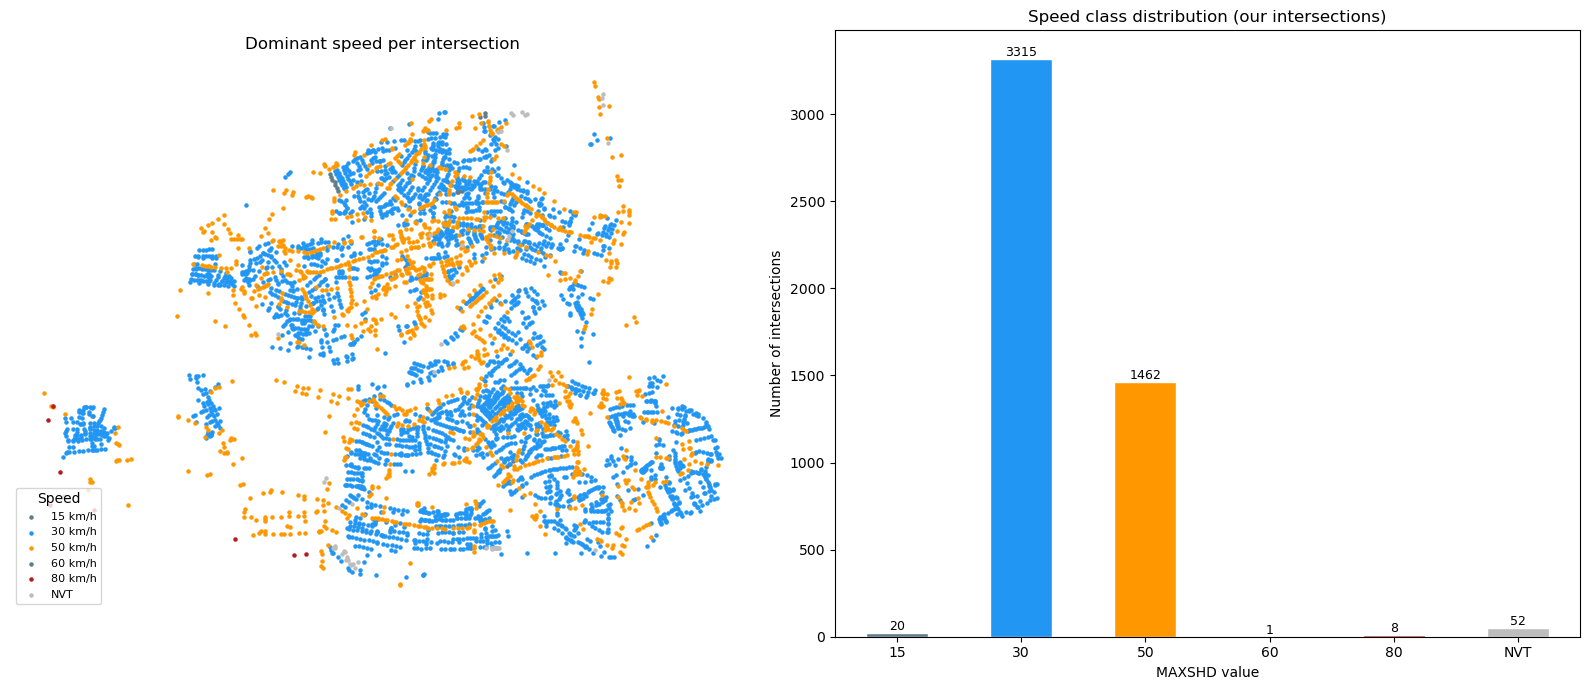

In [43]:
# Colour map for known speed values — covers likely Rotterdam values
SPEED_COLORS = {
    "30":  "#2196F3",   # blue  — low speed zone
    "50":  "#FF9800",   # orange — standard urban
    "70":  "#F44336",   # red   — higher speed
    "80":  "#B71C1C",   # dark red
    "100": "#4A148C",   # purple
    "NVT": "#BDBDBD",   # grey  — not applicable
    "NOA": "#9E9E9E",   # dark grey
}
DEFAULT_COLOR = "#607D8B"  # blue-grey for any other value

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: map coloured by dominant speed ---
ax = axes[0]
for speed_val, group in intersections.groupby("dominant_speed", dropna=False):
    color = SPEED_COLORS.get(str(speed_val), DEFAULT_COLOR)
    label = f"{speed_val} km/h" if str(speed_val) not in {"NVT", "NOA", "nan"} else str(speed_val)
    group.plot(ax=ax, color=color, markersize=5, label=label)

# Plot intersections with no speed data
no_speed = intersections[intersections["dominant_speed"].isna()]
if len(no_speed) > 0:
    no_speed.plot(ax=ax, color="black", markersize=5, marker="x", label="No data")

ax.set_title("Dominant speed per intersection")
ax.set_axis_off()
ax.legend(title="Speed", loc="lower left", fontsize=8)

# --- Right: bar chart of speed class counts ---
ax2 = axes[1]
counts = intersections["dominant_speed"].value_counts(dropna=False).sort_index()
colors = [SPEED_COLORS.get(str(v), DEFAULT_COLOR) for v in counts.index]
counts.plot(kind="bar", ax=ax2, color=colors, edgecolor="white")
ax2.set_title("Speed class distribution (our intersections)")
ax2.set_xlabel("MAXSHD value")
ax2.set_ylabel("Number of intersections")
ax2.tick_params(axis="x", rotation=0)
for p in ax2.patches:
    ax2.annotate(str(int(p.get_height())), (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## 7. Stratification class proposal

Based on the distribution above, decide on the speed classes for notebook 03.
The most natural split for urban Rotterdam is **30 km/h vs 50+ km/h**:
- 30 km/h = residential/low-speed zone — fundamentally different conflict dynamics
- 50+ km/h = standard or higher urban speed

This cell simulates that classification and shows stratum sizes.

In [44]:
# Simulate the proposed speed stratification for notebook 03.
# LOW_SPEED_VALUES: speed values considered "low speed zone" (30 km/h and below)
# Everything else with a numeric speed is "high speed zone"
# NVT/NOA/missing are labelled "onbekend" (unknown)

LOW_SPEED_VALUES = {"15", "30"}   # adjust here if needed

def classify_speed(val):
    if pd.isna(val) or val in {"NVT", "NOA"}:
        return "onbekend"
    if str(val) in LOW_SPEED_VALUES:
        return "30"       # low-speed zone label
    return "50+"          # standard or higher urban speed label

intersections["dim_speed"] = intersections["dominant_speed"].apply(classify_speed)

print("Proposed speed stratification:")
print(intersections["dim_speed"].value_counts().to_string())
print()

# Cross-tab with intersection type to preview full stratum sizes
if "street_count" in intersections.columns:
    intersections["dim_type"] = intersections["street_count"].apply(
        lambda x: "T" if x == 3 else "4+"
    )
    cross = pd.crosstab(intersections["dim_type"], intersections["dim_speed"])
    print("Crosstab — type × speed (before adding risk dimension):")
    print(cross)

Proposed speed stratification:
dim_speed
30          3335
50+         1471
onbekend      52

Crosstab — type × speed (before adding risk dimension):
dim_speed    30  50+  onbekend
dim_type                      
4+          674  584         6
T          2661  887        46


## 8. Summary — what needs to change in notebook 03

In [45]:
print("=" * 65)
print("SUMMARY: What needs to be added to notebook 03")
print("=" * 65)
print()
print("NEW INPUT FILE")
print(f"  data/raw/Snelheden_WKD/Snelheden.shp")
print(f"  CRS: EPSG:28992 — no reprojection needed")
print(f"  Geometry: LineString (road segment parts, not junctions)")
print()
print("JOIN STRATEGY")
print("  Recommended: tabular join via Wegvakken.gpkg")
print("  Step 1 — load Wegvakken (Rotterdam cache CSV or full file on first run)")
print("  Step 2 — build JTE_ID → [WVK_ID, ...] mapping from JTE_ID_BEG/JTE_ID_END columns")
print("  Step 3 — look up MAXSHD per WVK_ID from Snelheden.shp")
print("  Step 4 — aggregate per junction: mode of meaningful speeds (exclude NVT/NOA)")
print()
print("MAXSHD VALUES TO EXPECT IN ROTTERDAM")
print("  Numeric : 15, 30, 50, 70, 80, ... (km/h)")
print("  NVT     : Niet Van Toepassing (road not assigned a limit, e.g. path)")
print("  NOA     : Niet Op te Geven (speed not determinable)")
print("  null    : missing value")
print()
print("PROPOSED STRATIFICATION CLASSES (dim_speed)")
print("  '30'      — dominant speed is 30 km/h or lower (low-speed zone)")
print("  '50+'     — dominant speed is 50 km/h or higher")
print("  'onbekend'— NVT / NOA / no data")
print()
print("CONFIG PARAMETERS TO ADD TO NOTEBOOK 03")
print("  SNL_FILE         = path to Snelheden.shp")
print("  WVK_ROT_FILE     = path to wegvakken_rotterdam.csv (Rotterdam cache)")
print("  USE_SPEED        = True/False toggle")
print("  LOW_SPEED_VALUES = {'15', '30'}  # treated as '30' class")

SUMMARY: What needs to be added to notebook 03

NEW INPUT FILE
  data/raw/Snelheden_WKD/Snelheden.shp
  CRS: EPSG:28992 — no reprojection needed
  Geometry: LineString (road segment parts, not junctions)

JOIN STRATEGY
  Recommended: tabular join via Wegvakken.gpkg
  Step 1 — load Wegvakken (Rotterdam cache CSV or full file on first run)
  Step 2 — build JTE_ID → [WVK_ID, ...] mapping from JTE_ID_BEG/JTE_ID_END columns
  Step 3 — look up MAXSHD per WVK_ID from Snelheden.shp
  Step 4 — aggregate per junction: mode of meaningful speeds (exclude NVT/NOA)

MAXSHD VALUES TO EXPECT IN ROTTERDAM
  Numeric : 15, 30, 50, 70, 80, ... (km/h)
  NVT     : Niet Van Toepassing (road not assigned a limit, e.g. path)
  NOA     : Niet Op te Geven (speed not determinable)
  null    : missing value

PROPOSED STRATIFICATION CLASSES (dim_speed)
  '30'      — dominant speed is 30 km/h or lower (low-speed zone)
  '50+'     — dominant speed is 50 km/h or higher
  'onbekend'— NVT / NOA / no data

CONFIG PARAMET